In [1]:
%reload_ext autoreload
%autoreload 2
%cd ../../

/home/hazzu/Code/thesis


In [3]:
import os, cv2
import os.path as osp
from tqdm import tqdm
from lib.face_detector.retinaface import RetinaFaceDetector

face_detector = RetinaFaceDetector()

SELFIES_DUAL_DIR = "datasets/selfies_dual"
identities = os.listdir(SELFIES_DUAL_DIR)

faces_size = []

for identity in tqdm(identities):
    identity_dir = osp.join(SELFIES_DUAL_DIR, identity)
    if not osp.isdir(identity_dir):
        continue

    for image_name in os.listdir(identity_dir):
        image_path = osp.join(identity_dir, image_name)
        image = cv2.imread(image_path)

        faces = face_detector.detect(image)
        if len(faces) != 1:
            print(f"Ảnh chân dung {image_path} không hợp lệ ({len(faces)} khuôn mặt)")
        faces_size.append((faces[0].bbox["w"], faces[0].bbox["h"]))

100%|██████████| 95/95 [00:18<00:00,  5.23it/s]


In [4]:
print(f"Tổng số lượng sinh viên: {len(identities)} sinh viên")
print(f"Tổng số lượng ảnh chân dung: {len(faces_size)} ảnh")

Tổng số lượng sinh viên: 95 sinh viên
Tổng số lượng ảnh chân dung: 182 ảnh


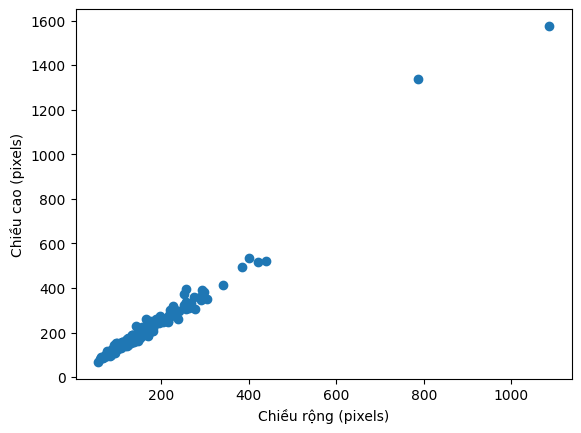

In [5]:
from matplotlib import pyplot as plt

plt.scatter(
    *zip(*faces_size),
    marker="o",
)
plt.xlabel("Chiều rộng (pixels)")
plt.ylabel("Chiều cao (pixels)")
plt.show()